# Heart Disease Prediction Using Machine Learning

## Objective
To predict the likelihood of heart disease using machine learning classification algorithms.

## Algorithms Used
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [3]:
df = pd.read_csv('heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:\n")

df.info()

Dataset Shape: (1025, 14)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


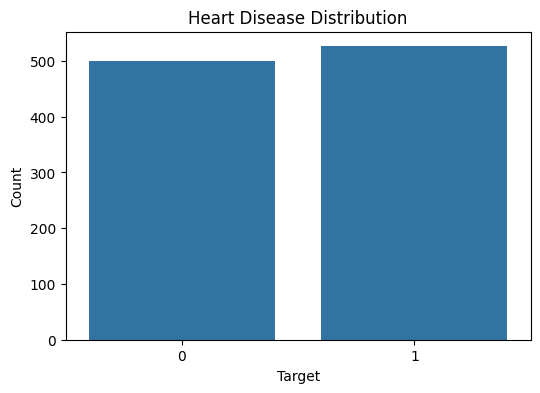

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

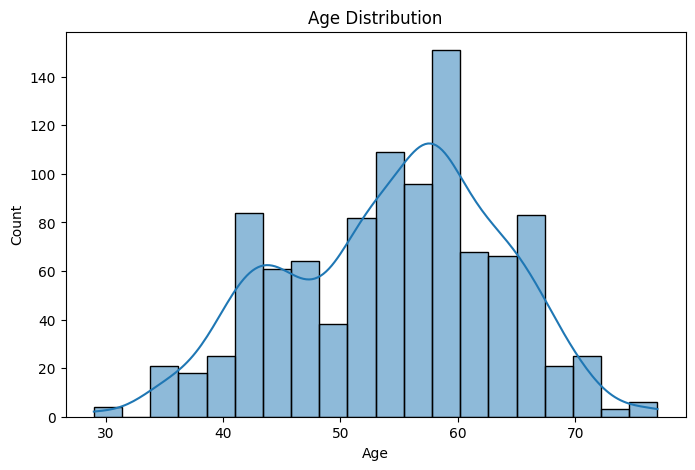

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

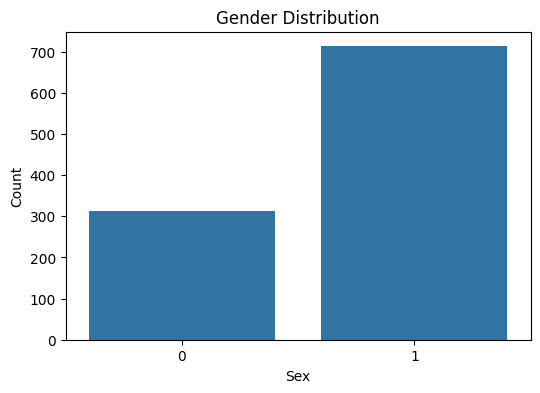

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")

plt.xlabel("Sex")

plt.ylabel("Count")

plt.show()

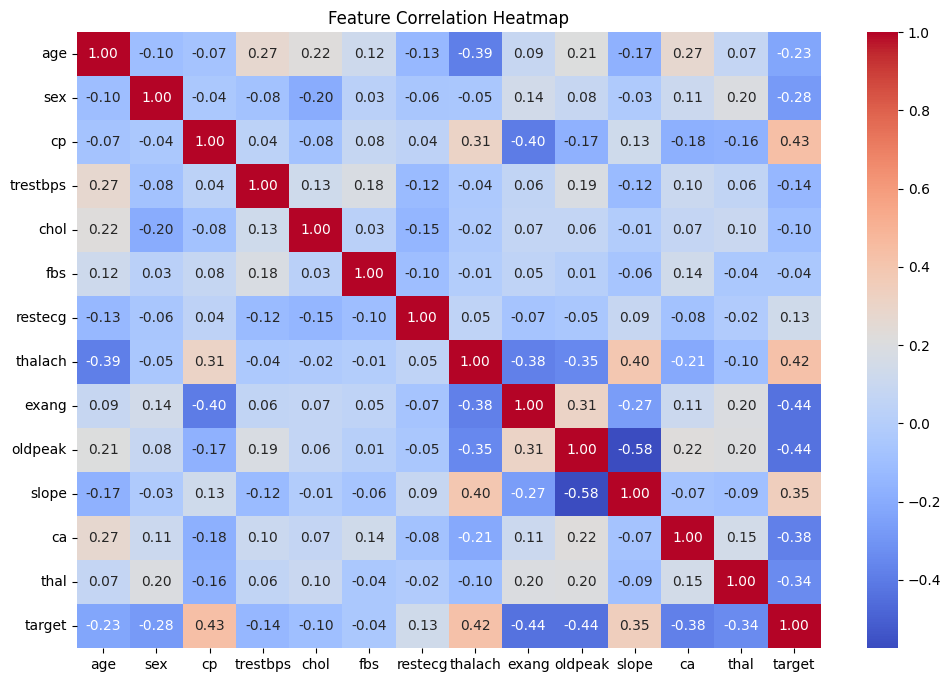

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [11]:
X = df.drop('target', axis=1)

y = df['target']

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (1025, 13)
Target Shape: (1025,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (820, 13)
Testing Data: (205, 13)


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy*100)

Logistic Regression Accuracy: 79.51219512195122


In [15]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [16]:
svm_model = SVC(probability=True)

svm_model.fit(X_train_scaled, y_train)

svm_predictions = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy * 100)

SVM Accuracy: 88.78048780487805


In [17]:
print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy * 100)

Random Forest Accuracy: 98.53658536585365


In [19]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [20]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy * 100,
        svm_accuracy * 100,
        rf_accuracy * 100
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,79.512195
1,SVM,88.780488
2,Random Forest,98.536585


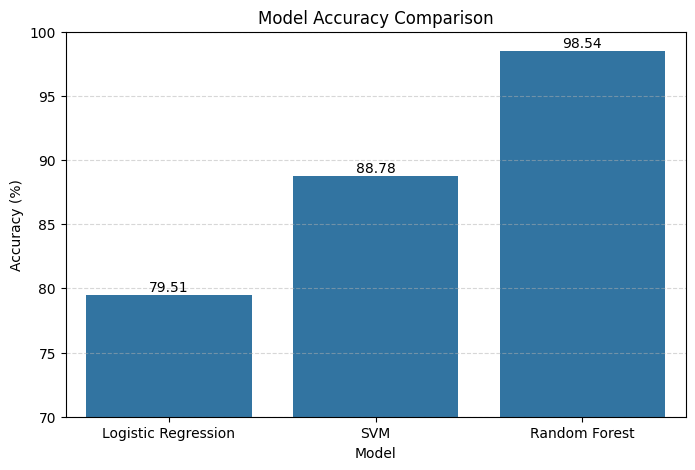

In [21]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.ylim(70,100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

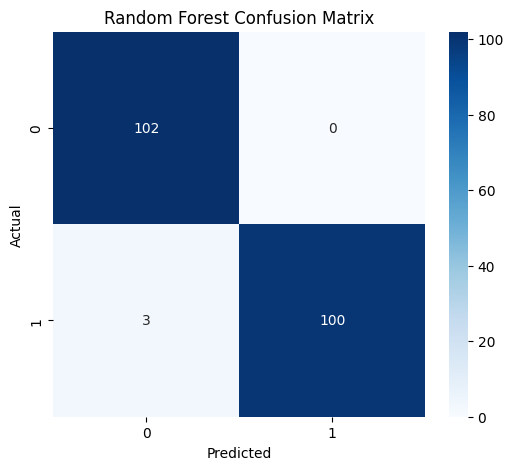

In [22]:
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

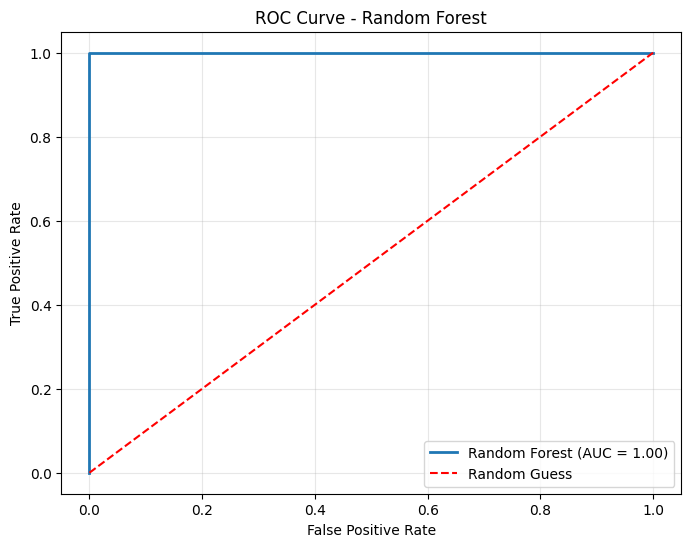

In [23]:
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

roc_auc = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc:.2f})'
)

plt.plot([0,1],[0,1],'r--',label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

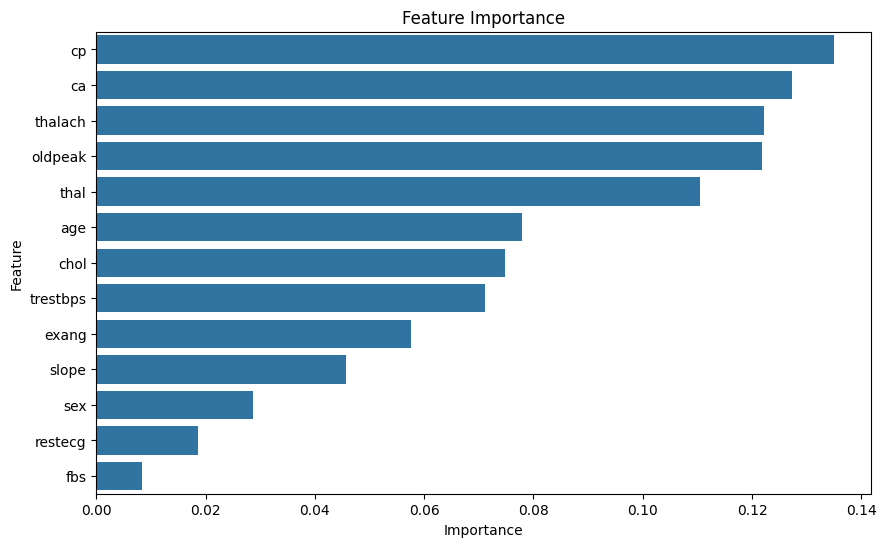

In [24]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [25]:
sample_patient = X.iloc[0]

sample_patient_scaled = scaler.transform(
    pd.DataFrame([sample_patient])
)

prediction = rf_model.predict(
    sample_patient_scaled
)

if prediction[0] == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease Detected")

Prediction: No Heart Disease Detected


# Conclusion

This project successfully developed a Machine Learning-based Heart Disease Prediction System using Logistic Regression, SVM, and Random Forest algorithms.

Among all models, Random Forest achieved the highest performance with an accuracy of approximately 98.5%.

Feature importance analysis revealed that chest pain type, number of major vessels, maximum heart rate, oldpeak, and thal were the most influential factors in predicting heart disease.

This project demonstrates the application of Machine Learning techniques in healthcare for disease prediction and risk assessment.